In [5]:
import numpy as np
import numba as nb
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl

%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append('..')

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


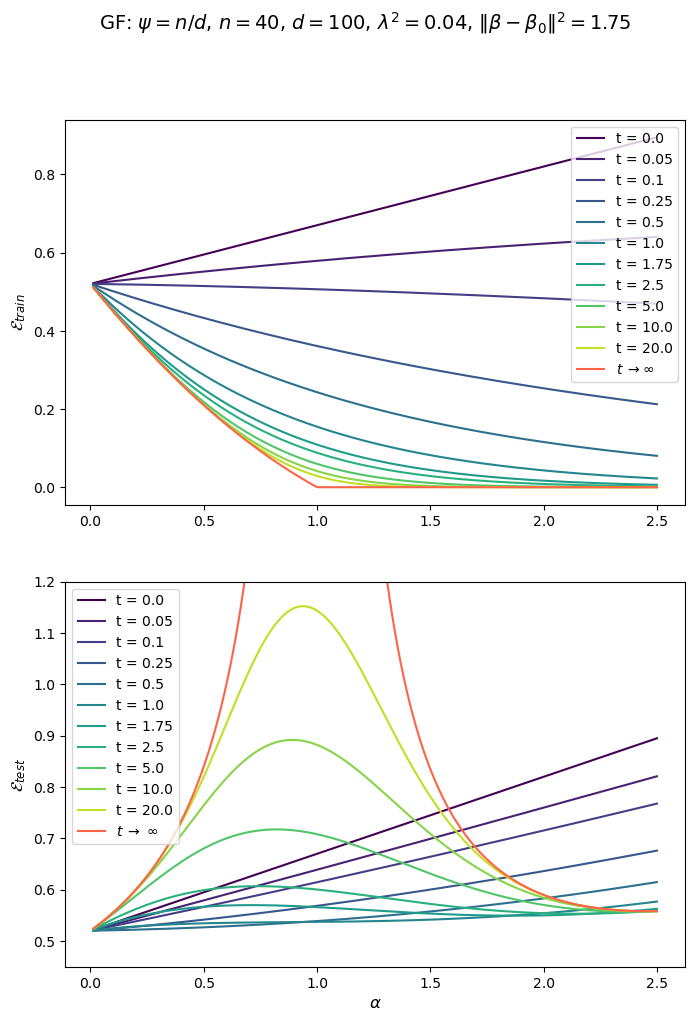

In [7]:
from theory.theory import Etest, Etest_inf_time, Etrain, Etrain_inf_time_precise

n = 40
d = 100
psi = d / n
l2 = 0.04
betadiff2 = 1.75
n_alpha_points = 200
alpha = np.linspace(0, psi, n_alpha_points)[1:]


lr = 10 ** (-2)
t = [0, 5, 10, 25, 50, 100, 175, 250, 500, 1e3, 2 * 1e3]


cmap_viridis = mpl.colormaps['viridis']
plt.figure(figsize=(8, 11))
ax1 = plt.subplot(211)
for i, tval in enumerate(t):
    ax1.plot(alpha, Etrain(alpha, psi, l2, tval * lr, betadiff2) / 2,
             c=cmap_viridis(i / len(t)), label=f't = {tval * lr}')
ax1.set_ylabel('$\\mathcal{{E}}_{{train}}$', fontsize=12)
ax1.plot(alpha, Etrain_inf_time_precise(alpha * n, n, d, l2) / 2,
         label='$t \\; \\to \\infty$', c='tomato')
ax1.legend()

ax2 = plt.subplot(212)
for i, tval in enumerate(t):
    ax2.plot(alpha, Etest(alpha, psi, l2, tval * lr, betadiff2) / 2,
             c=cmap_viridis(i / len(t)), label=f't = {tval * lr}')
ax2.plot(alpha, Etest_inf_time(alpha, psi, l2, betadiff2) / 2,
         label='$t \\; \\to \\; \\infty$', c='tomato')
ax2.set_ylim((0.45, 1.2))
ax2.legend()  

ax2.set_ylabel('$\\mathcal{{E}}_{{test}}$', fontsize=12)
ax2.set_xlabel('$\\alpha$', fontsize=12)
plt.suptitle(f'GF: $\\psi = n/d$, $ n = {n}$, $d={d}$, $\\lambda^2 = {l2}$,'
             f' $\\|\\beta - \\beta_0 \\|^2 = {betadiff2}$', fontsize=14)
plt.show()